In [1]:
#get all the tables:
from db_setup import conn, currencyexchange, customer, date, product, sales, store
#instead of saving csv files in sql and then importing one by one
import pandas as pd

customer_summary=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_summary.parquet")
rfm=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\rfm.parquet")
customer_value_segments=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_value_segments.parquet")
order_enriched=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\order_enriched.parquet")
customer_segments=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_segments.parquet")


c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  currencyexchange = pd.read_sql("SELECT * FROM currencyexchange", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer = pd.read_sql("SELECT * FROM customer", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  date = pd.read_sql("SELECT * FR

1- retention status table

In [3]:
customer_retention_status = customer_summary[[
    "customerkey",
    "last_purchase_date",
    "recency_days",
    "lifetime_revenue",
    "lifetime_profit",
    "order_count",
    "customer_country"
]].copy()

def retention_status(recency_days):
    if recency_days <= 30:
        return "Active"
    elif recency_days <= 90:
        return "Cooling"
    elif recency_days <= 180:
        return "Inactive"
    else:
        return "Churned"

customer_retention_status["retention_status"] = (customer_retention_status["recency_days"].apply(retention_status))

customer_retention_status

,customerkey,last_purchase_date,recency_days,lifetime_revenue,lifetime_profit,order_count,customer_country,retention_status
0,15,2021-03-08,1139,1299.708307,663.841613,1,Australia,Churned
1,180,2023-08-28,236,1103.346104,548.366791,2,Australia,Churned
2,185,2019-06-01,1785,666.453820,280.348295,1,Australia,Churned
3,243,2016-05-19,2893,148.903542,66.399387,1,Australia,Churned
4,387,2023-11-16,156,2341.268364,1217.535628,3,Australia,Inactive
...,...,...,...,...,...,...,...,...
49482,2099619,2020-07-10,1380,6709.935970,3943.559170,4,United States,Churned
49483,2099656,2024-02-06,74,10404.677800,5485.587800,4,United States,Cooling
49484,2099697,2022-09-13,585,38.201100,20.371100,1,United States,Churned
49485,2099711,2017-08-14,2441,6008.670000,2989.910000,2,United States,Churned


2- Summary

In [12]:
retention_summary = (
    customer_retention_status
    .groupby("retention_status")
    .agg(
        customers=("customerkey", "count"),
        total_revenue=("lifetime_revenue", "sum"),
        total_profit=("lifetime_profit", "sum")
    )
    .reset_index()
)

retention_summary["pct_customers"] = (
    retention_summary["customers"] / retention_summary["customers"].sum() * 100
).round(2)

retention_summary_sorted=retention_summary.sort_values("pct_customers",ascending=False)

retention_summary_sorted

,retention_status,customers,total_revenue,total_profit,pct_customers
1,Churned,42575,1.735948e+08,9.709297e+07,86.03
3,Inactive,3714,1.705817e+07,9.557911e+06,7.51
2,Cooling,2791,1.363102e+07,7.616569e+06,5.64
0,Active,407,1.989147e+06,1.112149e+06,0.82


Plot customer by retention status:

Text(0, 0.5, 'Customers')

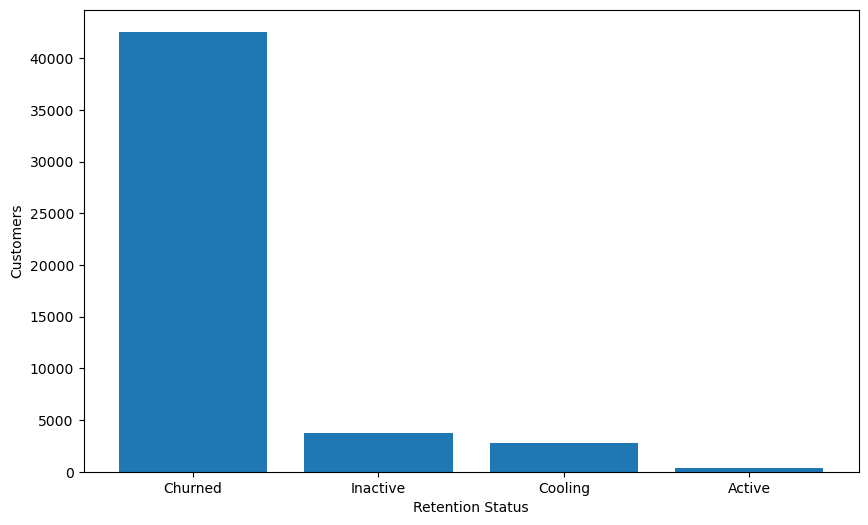

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(retention_summary_sorted["retention_status"], retention_summary_sorted["customers"])

plt.xlabel("Retention Status")
plt.ylabel("Customers")


Plot profit by retention status

Text(0, 0.5, 'Profit USD')

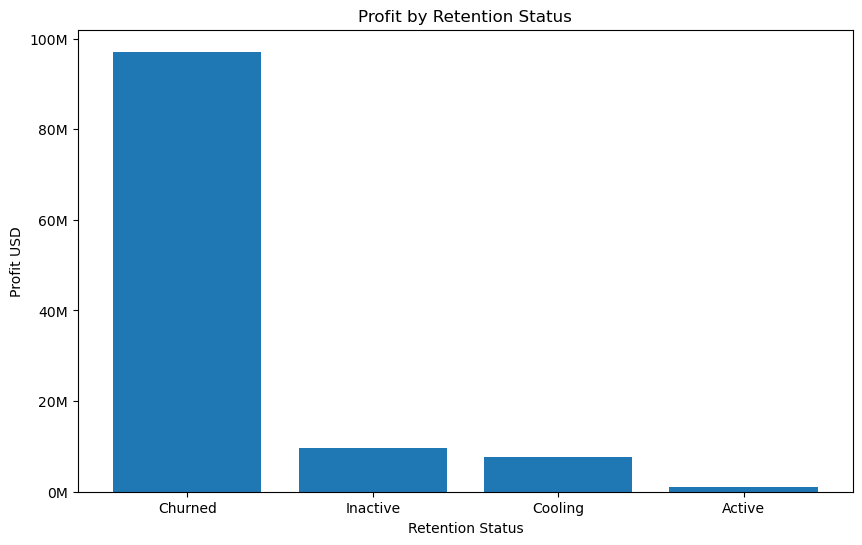

In [23]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.bar(retention_summary_sorted["retention_status"], retention_summary_sorted["total_profit"])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{int(y/1000000)}M'))
plt.title("Profit by Retention Status")
plt.xlabel("Retention Status")
plt.ylabel("Profit USD")


3- Top inactive customers

In [7]:
top_inactive_customers = (
    customer_retention_status[customer_retention_status["recency_days"] > 90]
    .sort_values("lifetime_profit", ascending=False)
    .head(25)
)

top_inactive_customers

,customerkey,last_purchase_date,recency_days,lifetime_revenue,lifetime_profit,order_count,customer_country,retention_status
12549,552225,2022-02-23,787,68447.861791,44015.885545,3,Germany,Churned
24399,1151535,2018-09-04,2055,63399.427405,41414.792466,1,United Kingdom,Churned
26234,1232832,2023-06-26,299,62460.008740,40472.291540,5,United States,Churned
39870,1743963,2023-08-28,236,65431.979488,39950.569888,6,United States,Churned
9364,427259,2022-01-27,814,57017.292030,36214.332700,2,Germany,Churned
42851,1852945,2017-02-13,2623,55994.750000,35913.486000,1,United States,Churned
24278,1144860,2019-12-26,1577,56183.496658,35182.345044,1,United Kingdom,Churned
12294,541870,2019-05-25,1792,52584.492186,34992.224681,1,Germany,Churned
24754,1171096,2021-12-24,848,53696.061212,34477.886321,5,United Kingdom,Churned
20106,929503,2019-08-30,1695,56100.381757,34030.515591,2,United Kingdom,Churned


4 -Segment risk

In [12]:
segment_risk = (
    customer_retention_status[["customerkey", "retention_status", "lifetime_profit"]]
    .merge(
        customer_segments[["customerkey", "combined_segment"]],
        on="customerkey",
        how="inner"
    )
    .groupby(["combined_segment", "retention_status"])
    .agg(
        customers=("customerkey", "count"),
        total_profit=("lifetime_profit", "sum")
    )
    .reset_index()
)

segment_risk.sort_values("total_profit", ascending=False)

,combined_segment,retention_status,customers,total_profit
10,High-Value Stable,Churned,5316,3.225136e+07
8,High-Value At Risk,Churned,4159,2.584827e+07
26,Potential Loyalist,Churned,8085,1.602477e+07
22,Needs Attention,Churned,10261,8.361711e+06
5,Champions,Churned,867,6.833153e+06
18,Loyal,Churned,2409,5.364606e+06
12,High-Value Stable,Inactive,734,4.262991e+06
11,High-Value Stable,Cooling Off,586,3.473544e+06
7,Champions,Inactive,315,2.252476e+06
20,Loyal,Inactive,939,2.012971e+06
